# Task 4: Insights and Recommendations

This notebook synthesizes sentiment and thematic analysis results into business-actionable insights for Ethiopian banking applications.

Banks analyzed:
- Commercial Bank of Ethiopia (CBE)
- Bank of Abyssinia (BOA)
- Dashen Bank

Objectives:
- Compare customer sentiment across banks
- Identify satisfaction drivers and pain points
- Extract dominant complaint themes
- Generate product recommendations
- Visualize customer experience trends

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

## Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/fintech_reviews_sentiment.csv")

df.head()

,review,rating,date,bank,source,sentiment,feature_tags
0,so nice,5,2026-05-19,CBE,Google Play,positive,[]
1,nice,5,2026-05-19,CBE,Google Play,positive,[]
2,cde,2,2026-05-19,CBE,Google Play,neutral,[]
3,"fast, easy, and save time.",5,2026-05-19,CBE,Google Play,positive,[]
4,jamal Abarhim,5,2026-05-19,CBE,Google Play,neutral,[]


## Sentiment Distribution by Bank

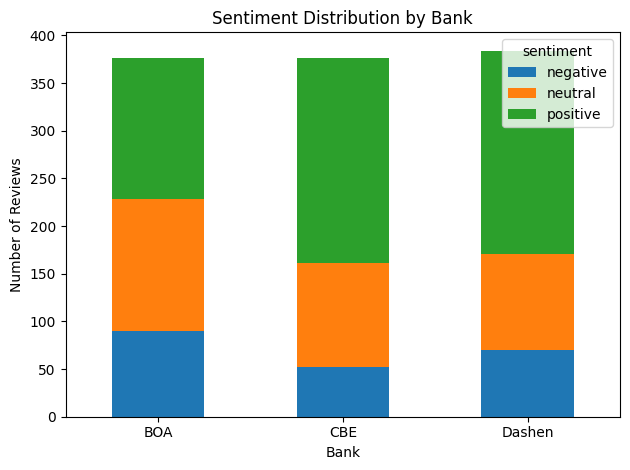

In [4]:
sentiment_counts = df.groupby(["bank", "sentiment"]).size().unstack()

sentiment_counts.plot(kind="bar", stacked=True)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.tight_layout()
import os

# create visuals folder
os.makedirs("../visuals", exist_ok=True)

plt.savefig("../visuals/sentiment_distribution.png")

plt.show()

## Rating Distribution per Bank

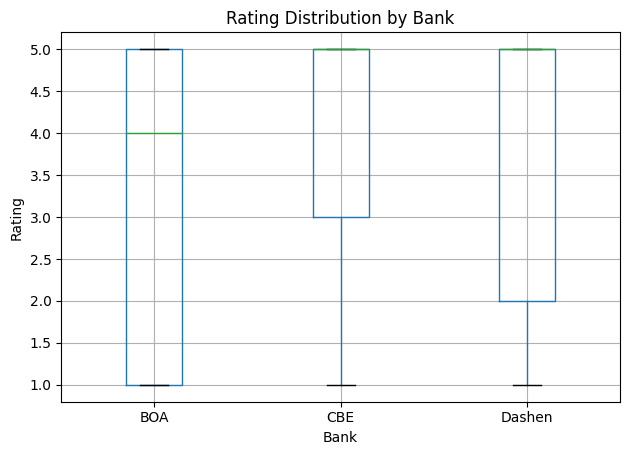

In [5]:
df.boxplot(column="rating", by="bank")

plt.title("Rating Distribution by Bank")
plt.suptitle("")

plt.xlabel("Bank")
plt.ylabel("Rating")

plt.tight_layout()

plt.savefig("../visuals/rating_distribution.png")

plt.show()

## Top Complaint Themes

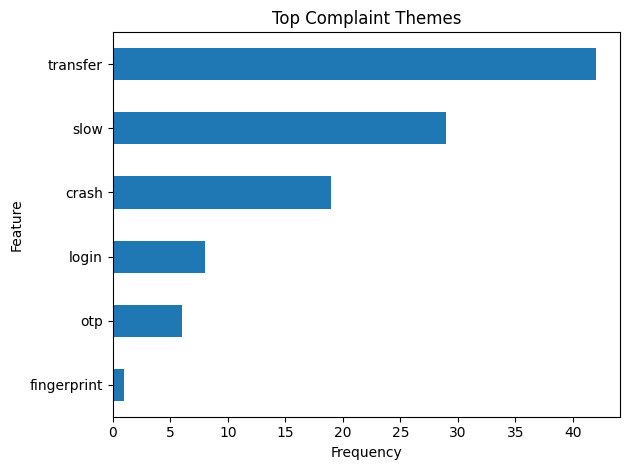

In [6]:
all_features = []

for tags in df["feature_tags"]:
    
    try:
        extracted = eval(tags) if isinstance(tags, str) else tags
        all_features.extend(extracted)
    except:
        pass

feature_counts = Counter(all_features)

top_features = pd.DataFrame(
    feature_counts.items(),
    columns=["feature", "count"]
).sort_values(by="count", ascending=True)

top_features.plot(
    kind="barh",
    x="feature",
    y="count",
    legend=False
)

plt.title("Top Complaint Themes")

plt.xlabel("Frequency")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("../visuals/keyword_frequency.png")

plt.show()

## Sentiment Trend Over Time

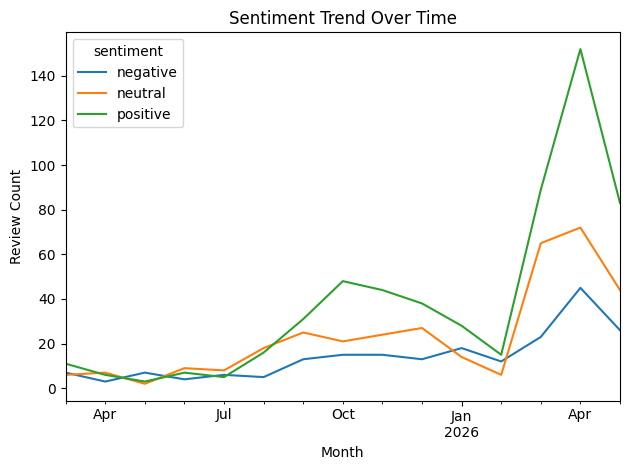

In [7]:
df["date"] = pd.to_datetime(df["date"])

trend = df.groupby([
    df["date"].dt.to_period("M"),
    "sentiment"
]).size().unstack()

trend.plot()

plt.title("Sentiment Trend Over Time")

plt.xlabel("Month")
plt.ylabel("Review Count")

plt.tight_layout()

plt.savefig("../visuals/sentiment_trend.png")

plt.show()